<a href="https://www.kaggle.com/code/nikita2901699/homework-nn?scriptVersionId=293935867" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [66]:
import torch  
from torchvision import datasets, transforms

In [67]:
data_dir = "/kaggle/input/fruit-recognition/train/train"

In [68]:
dataset = datasets.ImageFolder(data_dir)

In [69]:
len(dataset)

16854

In [70]:
img, label = dataset[3526]

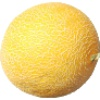

In [71]:
img 

In [72]:
dataset.classes

['Apple Braeburn',
 'Apple Granny Smith',
 'Apricot',
 'Avocado',
 'Banana',
 'Blueberry',
 'Cactus fruit',
 'Cantaloupe',
 'Cherry',
 'Clementine',
 'Corn',
 'Cucumber Ripe',
 'Grape Blue',
 'Kiwi',
 'Lemon',
 'Limes',
 'Mango',
 'Onion White',
 'Orange',
 'Papaya',
 'Passion Fruit',
 'Peach',
 'Pear',
 'Pepper Green',
 'Pepper Red',
 'Pineapple',
 'Plum',
 'Pomegranate',
 'Potato Red',
 'Raspberry',
 'Strawberry',
 'Tomato',
 'Watermelon']

In [73]:
data_train, data_test = torch.utils.data.random_split(dataset,[0.8, 0.2])

In [74]:
len(data_train)

13484

In [75]:
len(data_test)


3370

In [76]:
img, label = data_train[5000]


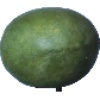

In [77]:
img

In [78]:
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(180, fill=255),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])


In [79]:
train_transform(img).shape

torch.Size([3, 64, 64])

In [80]:
test_transform = transforms.Compose(
    [transforms.Resize([64, 64]),
    transforms.ToTensor()
    ]
)

In [81]:
test_transform(img).shape


torch.Size([3, 64, 64])

In [82]:
from torch.utils.data import Dataset,DataLoader

class TransformDataset(Dataset):
    def __init__(self, dataset, transformer):
        super().__init__()
        self.dataset = dataset
        self.transformer = transformer

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        img, y = self.dataset[idx]

        new_img = self.transformer(img)
        
        return new_img, y

In [83]:
train_data = TransformDataset(data_train,train_transform)


In [84]:
test_data = TransformDataset(data_test,test_transform)


In [85]:
len(test_data)


3370

In [86]:
test_data[666]

(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          ...,
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],
 
         [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
          [1.0000, 1.0000, 1.0000,  ...,

In [87]:
train_loader = DataLoader(train_data, batch_size=256)


In [88]:
test_loader = DataLoader(test_data, batch_size=256)


In [89]:
for img,idx in test_loader:
     print(img.shape)
     print(idx.shape) 

torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([256, 3, 64, 64])
torch.Size([256])
torch.Size([42, 3, 64, 64])
torch.Size([42])


(64, 64, 3)


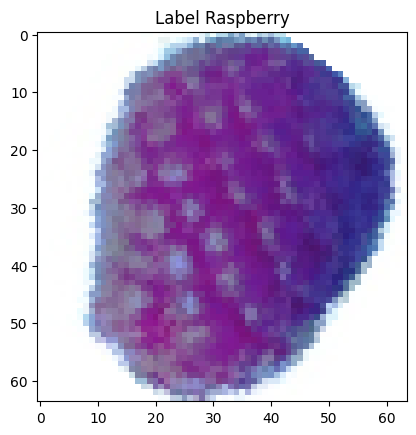

(64, 64, 3)


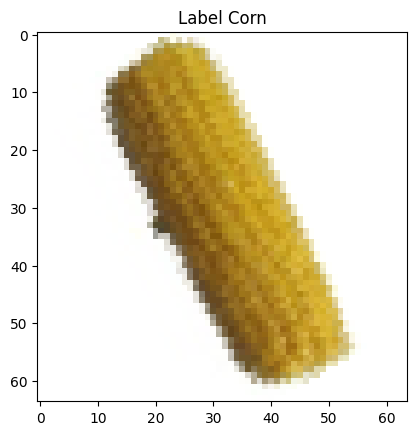

(64, 64, 3)


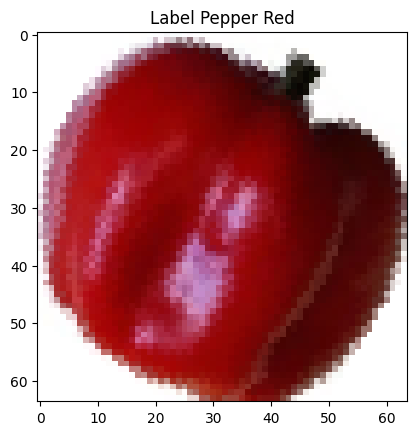

In [90]:
import matplotlib.pyplot as plt

for i in range(3):  # Show 3 images

    # Get the image data (tensor) and convert it back to a NumPy array for manipulation
    img, y = train_data[i]
    img = img.numpy()
    
    # Convert the color channels from (channels, height, width) to (height, width, channels) for pyplot
    img = img.transpose((1, 2, 0))
    print(img.shape)
    
    # Get the label name from the dataset class labels
    label = dataset.classes[y]

    # Plot the image with a title (including label name)
    plt.imshow(img)
    plt.title(f"Label {label}")
    plt.show()

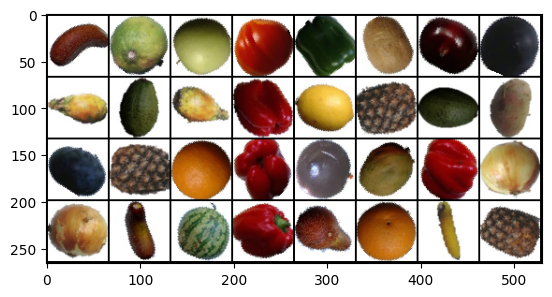

In [91]:
from torchvision.utils import make_grid

loader = torch.utils.data.DataLoader(train_data, shuffle=True, batch_size=32)

  
batch, labels = next(iter(loader))

grid = make_grid(batch).permute(1, 2, 0) # результатом є тензор

plt.imshow(grid)

In [92]:
3*64*64

10800

In [95]:
from torch import nn

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(12288, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 33)
)

device = "cuda"
model = model.to(device)

In [96]:
# функция ошибки для задачи многоклассовой классификации
loss_fn = nn.CrossEntropyLoss()

# оптимизатор Adam для обучения нейронной сети
optimizer = torch.optim.Adam(
    model.parameters(),   # параметры модели
    lr=0.2
)

# список для сохранения значений loss во время обучения
loss_list = []
loss_test_list = []

# цикл обучения по эпохам
for i in range(3):

    # перебор батчей из обучающего даталоадера
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        loss.backward()               # вычисление градиентов
        optimizer.step()              # обновление весов модели
        optimizer.zero_grad()         # очистка градиентов

        loss_list.append(loss.cpu().item())  # сохранение значения loss

    #test data
    for imgs, labels in train_loader:
        imgs = imgs.to(device)        # перенос изображений на GPU / CPU
        labels = labels.to(device)    # перенос меток на GPU / CPU

        result = model(imgs)          # прямой проход через модель
        loss = loss_fn(result, labels)  # вычисление функции потерь
        print(f"loss: {loss}")

        

        loss_test_list.append(loss.cpu().item())  # сохранение значения loss

loss: 3.5032331943511963
loss: 108038.96875
loss: 34270.87109375
loss: 8484.744140625
loss: 5654.388671875
loss: 5901.63671875
loss: 8985.46875
loss: 1972.7998046875
loss: 1470.059814453125
loss: 562.5164794921875
loss: 66.80746459960938
loss: 3.781869888305664
loss: 3.7004847526550293
loss: 3.7473318576812744
loss: 3.9047868251800537
loss: 3.862250804901123
loss: 3.8823294639587402
loss: 3.8361387252807617
loss: 3.758309841156006
loss: 3.9211182594299316
loss: 3.847656011581421
loss: 3.74349308013916
loss: 3.732027053833008
loss: 3.81728196144104
loss: 3.778710126876831
loss: 3.73162841796875
loss: 3.630181312561035
loss: 3.6439766883850098
loss: 3.6884496212005615
loss: 3.5775680541992188
loss: 3.6200666427612305
loss: 3.5683321952819824
loss: 3.576071262359619
loss: 3.5551228523254395
loss: 3.5231800079345703
loss: 3.582685947418213
loss: 3.564157009124756
loss: 3.5547571182250977
loss: 3.531804084777832
loss: 3.548006534576416
loss: 3.5107150077819824
loss: 3.530670642852783
loss: 

KeyboardInterrupt: 

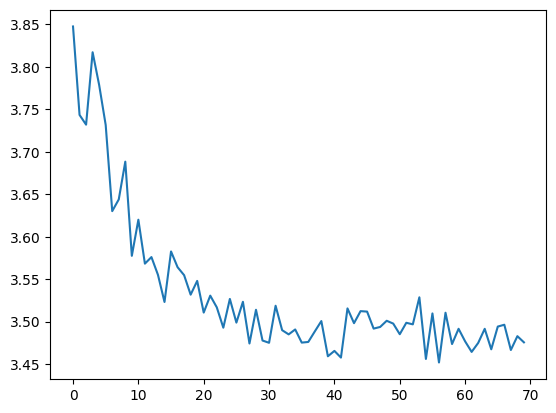

In [97]:
import matplotlib.pyplot as plt

new_list = loss_list[20 :]

plt.plot(new_list)


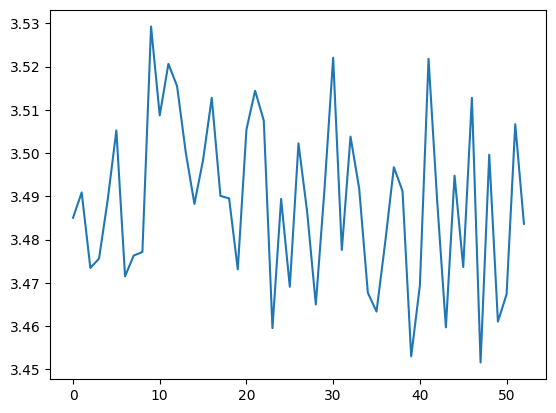

In [98]:
plt.plot(loss_test_list)

In [99]:
img, label = train_data[100]
img = img.unsqueeze(0)
img.shape

torch.Size([1, 3, 64, 64])

In [100]:
img = img.to(device)
prediction = model(img)
print(label)
print(nn.Softmax()(prediction))

30


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1773: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.0325, 0.0279, 0.0233, 0.0259, 0.0316, 0.0261, 0.0277, 0.0300, 0.0332,
         0.0241, 0.0284, 0.0238, 0.0577, 0.0237, 0.0360, 0.0287, 0.0323, 0.0223,
         0.0252, 0.0279, 0.0301, 0.0266, 0.0446, 0.0210, 0.0399, 0.0292, 0.0272,
         0.0358, 0.0262, 0.0260, 0.0337, 0.0465, 0.0251]], device='cuda:0',
       grad_fn=<SoftmaxBackward0>)
